# Tutorial on Loading and Editing of Scenes

This notebook explains how to load and edit scenes with Sionna's [ray tracing (RT) module](https://nvlabs.github.io/sionna/rt/index.html). You will:

- Use the `load_scene()` function to load a scene with and without merging objects
- Learn how to add and remove objects from a scene
- Learn how to translate, rotate, and scale objects within a scene

## Imports

In [95]:
import drjit as dr
import mitsuba as mi

# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

no_preview = True # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, ITURadioMaterial, SceneObject

## Loading Scenes and Merging Objects

Loading a scene with Sionna RT is done using the `load_scene()` function. By default, this function merges objects that share similar properties, such as radio materials. This is done because reducing the number of objects in a scene enables significant speed-ups for ray tracing.

Merging shapes can be disabled using the `merge_shapes` flag of `load_scene()`:

In [96]:
scene = load_scene("/home/js/js/sionna-rt/src/sionna/rt/scenes/kmu_260220/kmu_260220_flat.xml",
                   merge_shapes=False)

Let's now print the objects that make up the scene and their constituent materials. We can see that the objects have not been merged,
as radio materials appear multiple times in the composition of objects.

In [97]:
for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

None_buildings-itu_concreteitu_concrete
None_buildings-itu_metalitu_metal
elm__6         itu_concrete
elm__8         itu_concrete
elm__10        itu_concrete
elm__12        itu_concrete
elm__14        itu_concrete


Let's now reload the scene with the merging of objects enabled:

We can see that objects sharing the same radio materials have been merged, as each radio material appears only once in the composition of objects.

The function `load_scene()` also allows the exclusion of specific objects from the merging operation through the use of regular expressions. Please see the [Python documentation](https://docs.python.org/3/library/re.html) for details about the regular expression syntax.
As an example, let's exclude buildings with indices smaller than 3 from the merging process:

We can see that "building_1" and "building_2" have not been merged. As a result, "building_5" has not been merged either, as it has no other objects to be merged with.

## Editing Scenes

Let's load a more complex scene and visualize it.

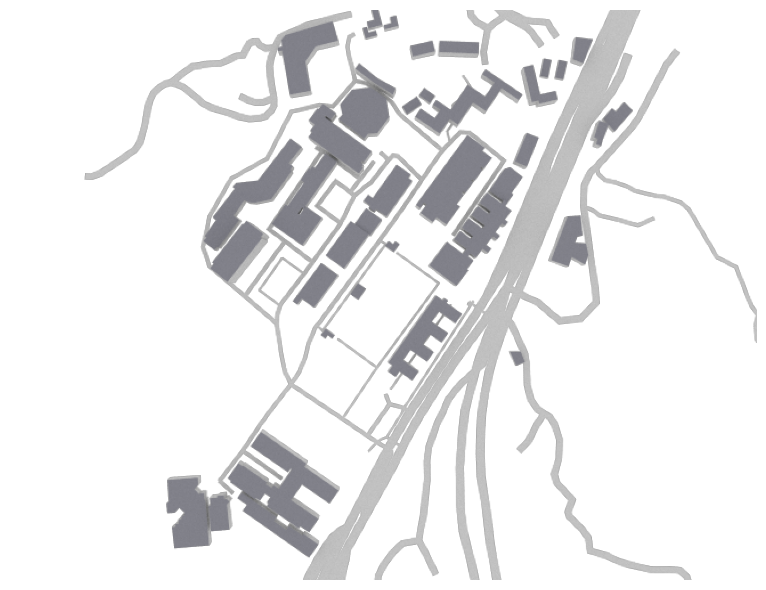

In [98]:
scene = load_scene("/home/js/js/sionna-rt/src/sionna/rt/scenes/kmu_260220/kmu_260220_flat.xml")

cam = Camera(position=[0, 0, 1000], look_at=[0, 0, 0])
if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

In [99]:
print(scene.objects.keys())

dict_keys(['no-name-17', 'None_buildings-itu_metal', 'None_buildings-itu_concrete'])


In [100]:
import importlib
import os
import mitsuba as mi
import sionna
from sionna.rt import load_scene, Camera

# 한글 주석: js_utils를 강제로 다시 읽어서 최신 함수 반영
import js_utils as js
js = importlib.reload(js)

# 한글 주석: 실제 어떤 파일이 import 됐는지 확인 (경로 문제 디버깅)
print("js_utils loaded from:", js.__file__)
print("has get_shape_translation:", hasattr(js, "get_shape_translation"))

# 한글 주석: scene 로드 (개별 elm__ 유지하려면 merge_shapes=False)
scene = load_scene(
    "/home/js/js/sionna-rt/src/sionna/rt/scenes/kmu_260220/kmu_260220_flat.xml",
    merge_shapes=False
)

road_id = "elm__6"

# 한글 주석: 객체 존재 확인
print("in scene.objects:", road_id in scene.objects)
print("in mi_scene.shapes:", road_id in [s.id() for s in scene.mi_scene.shapes()])

# 한글 주석: 좌표 추출
origin_xyz = js.get_shape_translation(scene, road_id)
center_xyz = js.get_shape_center(scene, road_id)
road_vertices = js.get_mesh_vertices(scene, road_id)
info = js.get_object_coordinates(scene, road_id)

print("origin_xyz:", origin_xyz)
print("center_xyz:", center_xyz)
print("n_vertices:", len(road_vertices))
if len(road_vertices) > 0:
    print("first vertex:", road_vertices[0])
print("summary:", info)

cam = Camera(position=[0, 0, 100], look_at=[0, 0, 0])
scene.preview()


js_utils loaded from: /data/js/sionna-rt/jinsup/js_utils.py
has get_shape_translation: True
in scene.objects: True
in mi_scene.shapes: True
[mi_utils] 'elm__6'에서 266개의 정점을 추출했습니다.
[mi_utils] 경고: 'elm__6'에서 to_world를 찾지 못해 중심 좌표를 반환합니다.
[mi_utils] 'elm__6'에서 266개의 정점을 추출했습니다.
[mi_utils] 'elm__6'에서 266개의 정점을 추출했습니다.
[mi_utils] 'elm__6'에서 266개의 정점을 추출했습니다.
[mi_utils] 'elm__6'에서 266개의 정점을 추출했습니다.
[mi_utils] 경고: 'elm__6'에서 to_world를 찾지 못해 중심 좌표를 반환합니다.
origin_xyz: [ 176.9419  -184.78406    0.3    ]
center_xyz: [ 176.9419  -184.78406    0.3    ]
n_vertices: 266
first vertex: [ 9.4636487e+02 -4.6960556e+02  3.0000001e-01]
summary: {'id': 'elm__6', 'origin_xyz': array([ 176.9419 , -184.78406,    0.3    ], dtype=float32), 'center_xyz': array([ 176.9419 , -184.78406,    0.3    ], dtype=float32), 'n_vertices': 266}


In [101]:
# 한글 주석: merge_shapes=False로 로드해야 elm__* 개별 ID를 유지할 수 있다
import importlib
from sionna.rt import load_scene, Camera
import js_utils as js

js = importlib.reload(js)

scene = load_scene(
    "/home/js/js/sionna-rt/src/sionna/rt/scenes/kmu_260220/kmu_260220_flat.xml",
    merge_shapes=False
)

cam = Camera(position=[0, 0, 1000], look_at=[0, 0, 0])
print("scene loaded")


scene loaded


In [102]:
import importlib
import js_utils as js
js = importlib.reload(js)

road_id = "elm__6"
road_vertices = js.get_mesh_vertices(scene, road_id)
js.show_vertices_on_scene_preview(
    scene,
    road_vertices,
    object_id=road_id,
    point_radius=5,
    preview_kwargs={"show_devices": False, "point_picker": True}
)


[mi_utils] 'elm__6'에서 266개의 정점을 추출했습니다.


✅ 'elm__6' 정점 266개를 preview에 표시했습니다.


In [103]:
# 도로 객체의 재질 가져오기
road_mat = scene.objects['elm__6'].radio_material

print(f"🏷️ 재질 이름 (Name): {road_mat.name}")
# 결과 예상: mat-roads_residential

# 실제 물리 속성 확인 (Sionna가 계산하는 값)
# 콘크리트라면 유전율(permittivity)이 약 5.3 정도 나와야 함
print(f"⚡ 유전율 (Permittivity): {road_mat.relative_permittivity.numpy()[0]:.4f}")
print(f"⚡ 전도율 (Conductivity): {road_mat.conductivity.numpy()[0]:.4f}")

🏷️ 재질 이름 (Name): itu_concrete
⚡ 유전율 (Permittivity): 5.2400
⚡ 전도율 (Conductivity): 0.1231


Next, we will add a few objects to the scene.

In Sionna RT, adding an object to a scene is achieved by instantiating a new [`SceneObject`](https://nvlabs.github.io/sionna/rt/api/scene_object.html) from a mesh and then adding the object to the scene using `Scene.add()`. When the `SceneObject` is instantiated, the radio material constituting the object needs to be specified.

In the following example, we will add cars made of metal to the previously loaded scene.

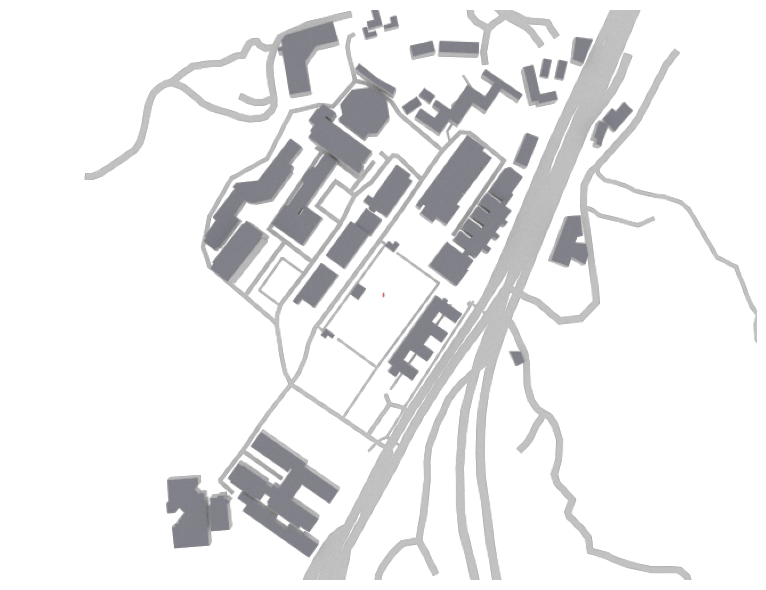

In [104]:
# Number of cars to add
num_cars = 10

# Radio material constituing the cars
# We use ITU metal, and use red color for visualization to
# make the cars easily discernible
car_material = ITURadioMaterial("car-material",
                                "metal",
                                thickness=0.01,
                                color=(0.8, 0.1, 0.1))

# Instantiate `num_cars` cars sharing the same mesh and material
cars = [SceneObject(fname=sionna.rt.scene.low_poly_car, # Simple mesh of a car
                    name=f"car-{i}",
                    radio_material=car_material)
        for i in range(num_cars)]

# Add the list of newly instantiated objects to the scene
scene.edit(add=cars)

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

We can see the red cars in the scene, but because they are all located at the same position, it appears that only a single car was added to the scene.

In the next cell, we will position the cars in the scene and also set their orientations.

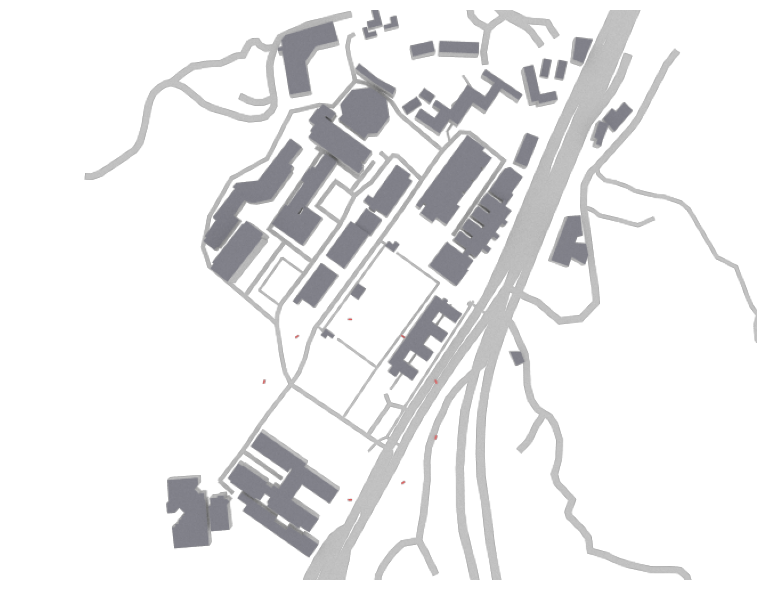

In [105]:
# Positions 
# Car are positioned in a circle around the central monument
# Center of the circle
c = mi.Point3f(-127, 37, 1.5)
# Radius of the circle
r = 100
# Angles at which cars are positioned
thetas = dr.linspace(mi.Float, 0., dr.two_pi, num_cars, endpoint=False)
# Cars positions
cars_positions = c + mi.Point3f(dr.cos(thetas), dr.sin(thetas), 0.)*r

# Orientations
# Compute points the car "look-at" to set their orientation
d = dr.normalize(cars_positions - c)
# Tangent vector to the circle at the car position
look_at_dirs = mi.Vector3f(d.y, -d.x, 0.)
look_at_points = cars_positions + look_at_dirs

# Set the cars positions and orientations
for i in range(num_cars):
    cars[i].position = mi.Point3f(cars_positions.x[i], cars_positions.y[i], cars_positions.z[i])
    cars[i].look_at(mi.Point3f(look_at_points.x[i], look_at_points.y[i], look_at_points.z[i]))

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

Objects can also be scaled. This is useful, for example, when the scale of the mesh from which the object is built does not suit the scene.

To illustrate this feature, let's scale the first car to be twice as large as the other cars.

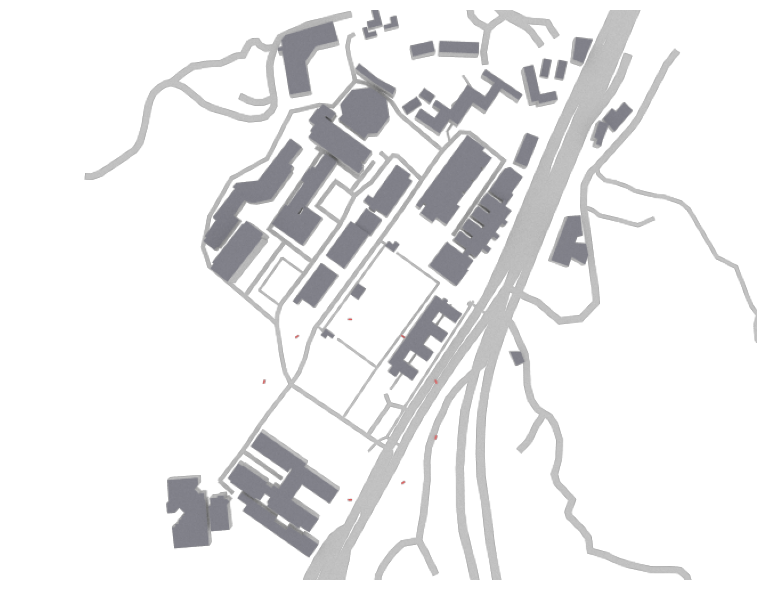

In [106]:
cars[0].scaling = 1.0

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

Finally, objects can be removed from the scene using the `Scene.edit()` function.

To illustrate this, let's remove the last car we have added.

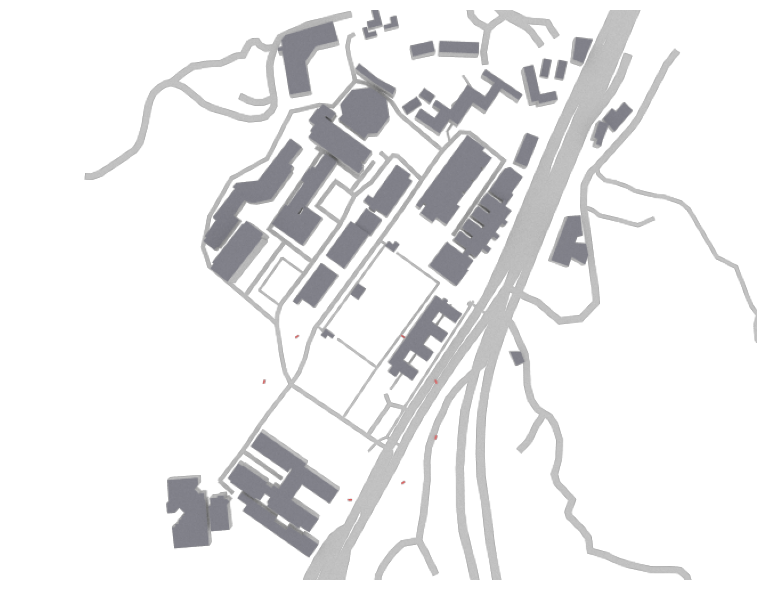

In [107]:
scene.edit(remove=[cars[0]])

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

## Path Computation with the Edited Scene

Let's now compute radio propagation paths on the edited scene.

We start by adding a transmitter on the roof of an arbitrarily selected building, as well as a receiver on top of each car.
We also set the transmitter and receiver arrays.

In [108]:
# Add a transmitter on top of a building
bs_height = 20.0      # 차보다 20m 위
idx_bs    = 0         # 0번째 차 기준 (원하는 인덱스로 바꿔도 됨)

tx_x = cars_positions.x[idx_bs]
tx_y = cars_positions.y[idx_bs]
tx_z = cars_positions.z[idx_bs] + bs_height

scene.remove("tx")
scene.add(Transmitter(
    "tx",
    position=[float(tx_x), float(tx_y), float(tx_z)],
    display_radius=10
))
# Add a receiver on top of each car
for i in range(num_cars):
    scene.remove(f"rx-{i}")
    scene.add(Receiver(f"rx-{i}", position=[cars_positions.x[i],
                                            cars_positions.y[i],
                                            cars_positions.z[i] + 3],
                      display_radius=2))


# Set the transmit and receive antenna arrays
scene.tx_array = PlanarArray(num_cols=1,
                             num_rows=1,
                             pattern="iso",
                             polarization="V")
scene.rx_array = scene.tx_array

We are now ready to compute paths.

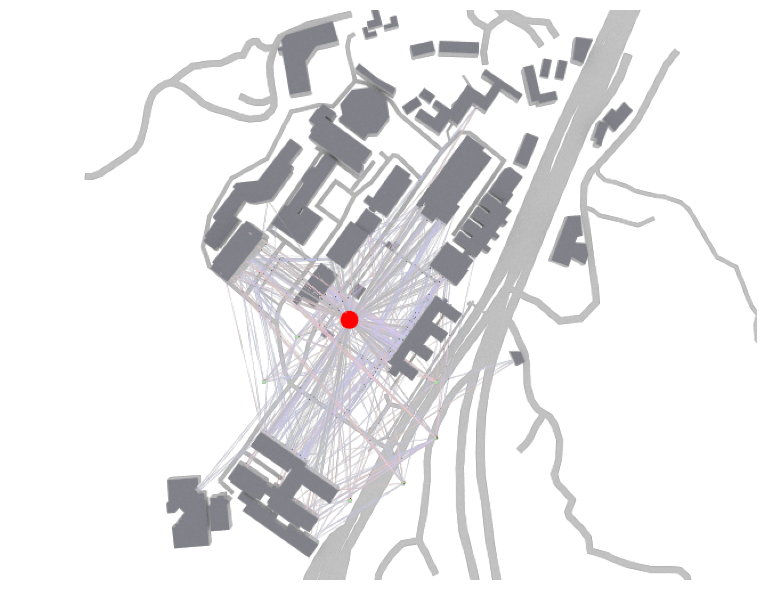

In [109]:
p_solver = PathSolver()
paths = p_solver(scene, max_depth=5)

if no_preview:
    scene.render(camera=cam, paths=paths);
else:
    scene.preview(paths=paths);

## Summary

A scene is loaded using the `load_scene()` function, which by default merges objects sharing similar properties, such as radio materials. Merging of objects can be disabled by setting the `merge_shapes` flag to `False`; however, this can incur a significant slowdown in the ray tracing process. Alternatively, specific objects can be removed from the merging process using the `merge_shapes_exclude_regex` parameter.

Scene objects can be instantiated from meshes and added to a scene using `Scene.edit()`. This function can also be used to remove objects from a scene. Note that to optimize performance and reduce processing time, it is recommended to use a single call to this function with a list of objects to add and/or remove, rather than making multiple individual calls to edit scene objects.